# **Facial Emotion Detection**

# **Deep Learning Project: Emotion Detection in Facial Images**

--------------
## **Context**
--------------
Deep Learning has found applications in many predictive tasks relating to more unstructured forms of data over the last few years, such as images, text, audio and video. Many of these tasks seem to be in the vein of a larger direction of predictive modeling that aims to match human-level performance on such tasks, because humans have evolved to specialize in performing intelligent actions on such unstructured data. As a specific branch of AI (also called Affective Computing or Emotion AI) Artificial Emotional Intelligence stands for the study and development of technologies and computers that can read human emotions by means of analyzing body gestures, facial expressions, voice tone, etc. and react appropriately to them.

In the field of human-machine interaction, facial expression recognition is critical. From recent research, it has been found that as much as 55% of communication of sentiment takes place through facial expressions and other visual cues. Therefore, training a model to identify facial emotions accurately is an important step towards the development of emotionally intelligent behavior in machines with AI capabilities. Automatic facial expression recognition systems could have many applications, including but not limited to any use case that requires human behavior understanding, detection of mental disorders, and creating a higher quality of virtual assistant for customer-facing businesses.

----------------
## **Objective**
----------------
The goal of this project is to use Deep Learning and Artificial Intelligence techniques to create a computer vision model that can accurately detect facial emotions. The model should be able to perform multi-class classification on images of facial expressions, to classify the expressions according to the associated emotion.

-------------
## **Dataset**
-------------
The data set consists of 3 folders of black and white images: 'test', 'train', and 'validation'. Each of these folders has four subfolders:
- ‘happy’: Images of people who have happy facial expressions.
- ‘sad’: Images of people with sad or upset facial expressions.
- ‘surprise’: Images of people who have shocked or surprised facial expressions.
- ‘neutral’: Images of people showing no prominent emotion in their facial expression at all.

## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

In [1]:
#from google.colab import drive # Google Drive
#drive.mount("/content/drive")

## **Importing the Libraries**

In [1]:
import os  # Interact with the operating system and filesystem
import pathlib
import PIL
import PIL.Image
import random  # Random number generator
import numpy as np  # Numerical calculations
import pandas as pd  # For loading data from CSV into DataFrames]
import tensorflow as tf  # TensorFlow main module
import keras # main neural network module
from tensorflow.keras.models import Sequential  # Create sequential layered neural networks
from tensorflow.keras.layers import (
   Input,
   Conv2D,  # 2D convolutional layers for images
   LeakyReLU,  # Activation function layers
   MaxPooling2D,  # Maximum pooling layers
   Flatten,  # Flatten layers into 1D vectors
   Dense,  # Fully connected layer
   Dropout,  # Delete/ignore certain neurons to avoid overfitting
   BatchNormalization  # Normalize layer inputs for improved performance
)
from tensorflow.keras.optimizers import ( # Optimizers
    Adam,
    Adadelta,
    Lamb,
    RMSprop,
    SGD
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical  # One-hot encoder for categorical features
from tensorflow.keras.losses import CategoricalCrossentropy, SparseCategoricalCrossentropy  # Loss function
from tensorflow.keras.metrics import Accuracy  # Accuracy metric to evaluate model performance
from tensorflow.keras.applications import VGG16, ResNet50V2, EfficientNetB0, EfficientNetB7, EfficientNetV2L  # Pre-trained models
import keras_tuner as kt
from sklearn.preprocessing import OneHotEncoder  # One-hot encoder for categorical features
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import (
   classification_report,  # Generate a detailed classification report
   confusion_matrix  # Visualize model performance with a confusion matrix
)
import matplotlib.pyplot as plt  # Create charts
import seaborn as sns # Create visualizations

import warnings
warnings.filterwarnings('ignore')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at te

### **Let us load and unzip the data**

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same on your Google drive before executing the code in the next cell.
- In case of any error, please make sure that the path of the file is correct as the path may be different for you.

In [2]:
#!unzip /content/drive/MyDrive/Facial_emotion_images.zip

## **Visualizing our Classes**

Let's look at our classes.

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

In [3]:
# Define filesystem variables for the image directories and files
base_dir = '/Users/socrates/Documents/workspace/Tensorflow/data/Facial_emotion_images'
train_dir = os.path.join(base_dir, 'train/')
test_dir = os.path.join(base_dir, 'test/')
val_dir = os.path.join(base_dir, 'validation/')
train_data_dir = pathlib.Path(train_dir)
test_data_dir = pathlib.Path(test_dir)
val_data_dir = pathlib.Path(val_dir)
train_image_count = len(list(train_data_dir.glob('*/*.jpg')))
test_image_count = len(list(test_data_dir.glob('*/*.jpg')))
val_image_count = len(list(val_data_dir.glob('*/*.jpg')))
print('The training set has', train_image_count, 'images, the testing set has', test_image_count, 'images, and the validation set has ', val_image_count, ' images.')

# Set the batch size and image dimmensions (found from manually looking at a few sample files)
batch_size = 32
img_height = 48
img_width = 48

# Create RGB training set from corresponding image directory
train_ds_rgb = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    validation_split=0.2,
    subset="training",
    seed=20250807,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

# Create RGB validatation set from corresponding image directory
val_ds_rgb = tf.keras.utils.image_dataset_from_directory(
    val_data_dir,
    validation_split=0.2,
    subset="validation",
    seed=20250807,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

# Create greyscale training set from corresponding image directory
train_ds_grey = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    validation_split=0.2,
    subset="training",
    seed=20250807,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)

# Create greyscale validation set from corresponding image directory
val_ds_grey = tf.keras.utils.image_dataset_from_directory(
    val_data_dir,
    validation_split=0.2,
    subset="validation",
    seed=20250807,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)

# Make sure the training and validation sets have the same number of categories
train_class_names = train_ds_rgb.class_names
val_class_names = val_ds_rgb.class_names
print('The classes in the training set are:', train_class_names)
print('The classes in the validation set are:', val_class_names)

# Count the number of images of each emotion
happy_count = 0
sad_count = 0
surprise_count = 0
neutral_count = 0

# Count the number of images in each category
for _, labels in train_ds_rgb:
  for label in labels:
    if train_class_names[label] == 'happy':
      happy_count += 1
    elif train_class_names[label] == 'sad':
      sad_count += 1
    elif train_class_names[label] == 'surprise':
      surprise_count +=1
    else:
      neutral_count += 1

# Print the number of images in each category
print(f"Number of happy images in training set: {happy_count}")
print(f"Number of sad images in training set: {sad_count}")
print(f"Number of surprise images in training set: {surprise_count}")
print(f"Number of neutral images in training set: {neutral_count}")

# Create a helper function to display random sample images
def plot_images(emotion):
  images = os.listdir(train_dir + emotion)
  plt.figure(figsize=(5, 5))
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    idx = random.randint(1, len(images))
    img = load_img(train_dir + emotion + "/" + images[idx], target_size = (img_height, img_width))
    plt.imshow(img)
    plt.title(emotion)
    plt.axis("off")

The training set has 15109 images, the testing set has 128 images, and the validation set has  4977  images.
Found 15109 files belonging to 4 classes.
Using 12088 files for training.
Found 4977 files belonging to 4 classes.
Using 995 files for validation.
Found 15109 files belonging to 4 classes.
Using 12088 files for training.
Found 4977 files belonging to 4 classes.
Using 995 files for validation.
The classes in the training set are: ['happy', 'neutral', 'sad', 'surprise']
The classes in the validation set are: ['happy', 'neutral', 'sad', 'surprise']
Number of happy images in training set: 3126
Number of sad images in training set: 3193
Number of surprise images in training set: 2571
Number of neutral images in training set: 3198


2026-06-29 19:02:08.124816: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### **Happy**

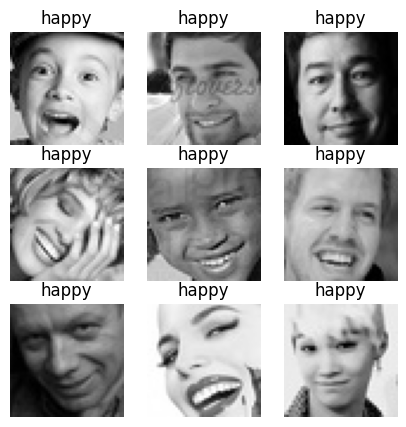

In [4]:
plot_images('happy')

**Observations and Insights:**
- A smile is a reliable indicator of happiness.
- Most eyes of the happy sample images are open wide.

### **Sad**

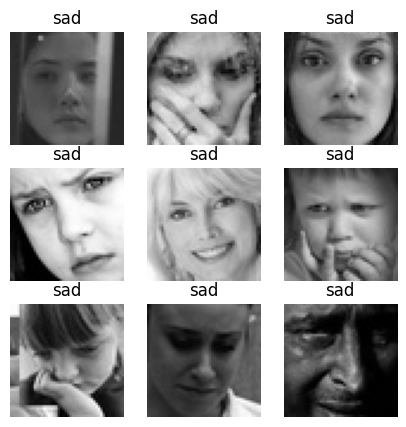

In [5]:
plot_images('sad')

**Observations and Insights:**
- Tears are a reliable indicator of sadness.
- Closing or squinting the eyes may indicate an attempt to hold back negative emotions such as sadness.

### **Neutral**

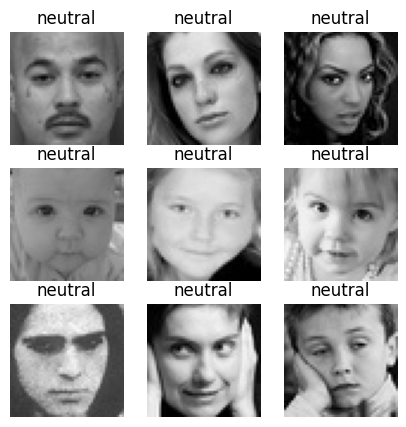

In [6]:
plot_images('neutral')

**Observations and Insights:**
- Many of the people in the neutral images are simply looking ahead without distinctive facial reactions.

### **Surprised**

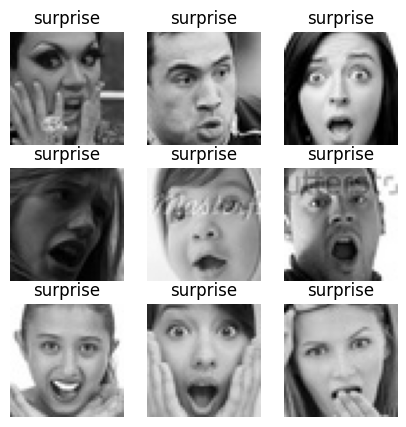

In [7]:
plot_images('surprise')

**Observations and Insights:**
- An open mouth seems to be a common feature of surprise.
- Hands on the face or raised in the air ay also indicate surprise.

## **Checking Distribution of Classes**

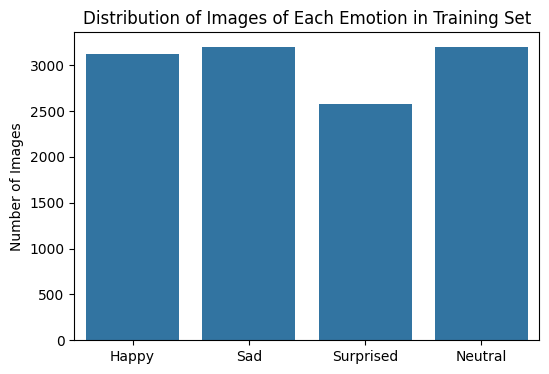

In [8]:
# Data for plotting
class_counts = {'Happy': happy_count, 'Sad': sad_count, 'Surprised': surprise_count, 'Neutral': neutral_count}
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(6, 4))
sns.barplot(x=classes, y=counts)
plt.title('Distribution of Images of Each Emotion in Training Set')
plt.ylabel('Number of Images')
plt.show()

**Observations and Insights:**
- The datasets are roughly balanced.
- The surprised category may benefit from data augmentation if the model underperforms in predicting this class.

**Think About It:**
* Are the classes equally distributed? If not, do you think the imbalance is too high? Will it be a problem as we progress?
* Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?

## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

In [9]:
normalized_train_ds_rgb = train_ds_rgb.map(lambda x, y: (x / 255.0, to_categorical(y, num_classes=len(train_class_names))))
normalized_val_ds_rgb = val_ds_rgb.map(lambda x, y: (x / 255.0, to_categorical(y, num_classes=len(val_class_names))))
normalized_train_ds_grey = train_ds_grey.map(lambda x, y: (x / 255.0, to_categorical(y, num_classes=len(train_class_names))))
normalized_val_ds_grey = val_ds_grey.map(lambda x, y: (x / 255.0, to_categorical(y, num_classes=len(val_class_names))))

## **Model Building**

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead?
* What are the advantages of CNNs over ANNs and are they applicable here?

### **Creating the Base Neural Network**

In [10]:
#Define the base model
base_model = Sequential([
    #Input(shape=(img_height, img_width, 3)), # The input layer needs 3 channels for the RGB data
    Input(shape=(img_height, img_width, 1)), # The input layer needs 1 channel for the greyscale data
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='silu'),
    Dropout(0.5),
    Dense(len(train_class_names), activation='softmax') # Output layer with softmax for classification
])

### **Compiling and Training the Model**

In [11]:
# Compile the base model
#base_model.compile(optimizer=keras.optimizers.Adadelta(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
#base_model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
#base_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
base_model.compile(optimizer=keras.optimizers.Lamb(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
base_model.summary()

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    ModelCheckpoint('best_base_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# Fit and train the base model
history_base = base_model.fit(
    #normalized_train_ds_rgb,  # Use the normalized and one-hot encoded RGB training dataset
    normalized_train_ds_grey,  # Use the normalized and one-hot encoded greyscale training dataset
    #validation_data=normalized_val_ds_rgb, # Use the normalized and one-hot encoded RGB validation dataset
    validation_data=normalized_val_ds_grey, # Use the normalized and one-hot encoded greyscale validation dataset
    epochs=30, # You can adjust the number of epochs
    callbacks=callbacks
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,460 (1.36 MB)

 Trainable params: 355,460 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
375/378 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2633 - loss: 1.3859
Epoch 1: val_loss improved from None to 1.37263, saving model to best_base_model.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.2708 - loss: 1.3844 - val_accuracy: 0.4020 - val_loss: 1.3726
Epoch 2/30
377/378 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2814 - loss: 1.3809
Epoch 2: val_loss improved from 1.37263 to 1.36817, saving model to best_base_model.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.2871 - loss: 1.3800 - val_accuracy: 0.4030 - val_loss: 1.3682
Epoch 3/30
376/378 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3023 - loss: 1.3754
Epoch 3: val_loss improved from 1.36817 to 1.36147, saving model to best_base_model.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.3099 - loss: 1.3738 - val_accuracy: 0.4090 - val_loss: 1.3615
Epoch 4/30
377/378 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3277 - loss: 1.3673
Epoch 4: val_loss improved from

### **Evaluating the Model on the Test Set**

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5789 - loss: 1.0440
Base Model Test Loss: 1.0439788103103638
Base Model Test Accuracy: 0.5788944959640503
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

           0       0.36      0.33      0.35       380
           1       0.21      0.21      0.21       246
           2       0.20      0.21      0.20       225
           3       0.16      0.18      0.17       144

    accuracy                           0.25       995
   macro avg       0.23      0.23      0.23       995
weighted avg       0.26      0.25      0.26       995



2025-09-14 11:10:34.053280: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


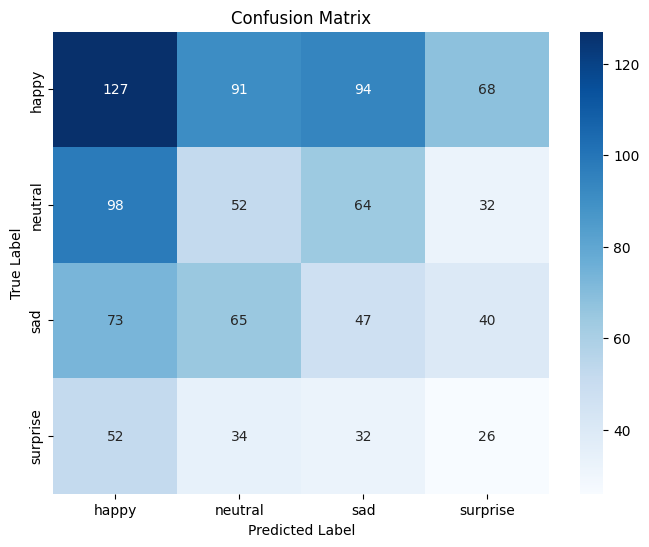

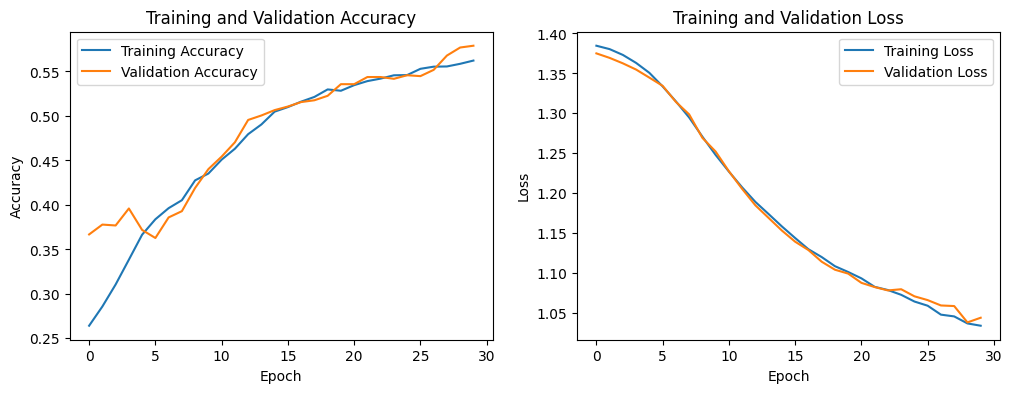

In [13]:
# Evaluate the base model on the test data
#base_loss, base_accuracy = base_model.evaluate(normalized_val_ds_rgb)
base_loss, base_accuracy = base_model.evaluate(normalized_val_ds_grey)

print(f"Base Model Test Loss: {base_loss}")
print(f"Base Model Test Accuracy: {base_accuracy}")

# Get predictions on the test data
#predictions = base_model.predict(normalized_val_ds_rgb)
predictions = base_model.predict(normalized_val_ds_grey)
predicted_labels = np.argmax(predictions, axis=1)

# Get the true labels from the test dataset
#true_labels = np.concatenate([y for x, y in normalized_val_ds_rgb], axis=0)
true_labels = np.concatenate([y for x, y in normalized_val_ds_grey], axis=0)
true_labels = np.argmax(true_labels, axis=1)

# Generate the confusion matrix
print(classification_report(true_labels, predicted_labels))
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_class_names, yticklabels=val_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_base.history['accuracy'], label='Training Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_base.history['loss'], label='Training Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Observations and Insights:**
- The model's training and testing validation are around 55%. 
- The model does much better at predicting happiness than other emotions.
- Manual testing with different optimization algorithms revealed Lamb produced the highest accuracy score.
- Manual testing with different activation functions for the output layer revealed no significant difference between sigmoid, softmax, squareplus, or tanh.
- There was no significant difference in the accuracy or F1 score when using the greyscale images compared to the RGB ones.
- There is virtually no overfit in this model.

### **Creating the second Convolutional Neural Network**

- Try out a slightly larger architecture

In [14]:
# Define Model 2 with Batch Normalization and Leaky ReLU
model_2 = Sequential([
    #Input(shape=(img_height, img_width, 3)), # The input layer needs 3 channels for the RGB data
    Input(shape=(img_height, img_width, 1)), # The input layer needs 1 channel for the greyscale data    Conv2D(32, (3, 3)),
    BatchNormalization(), # Added Batch Normalization
    LeakyReLU(0.1),          # Using Leaky ReLU activation
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3)),
    BatchNormalization(), # Added Batch Normalization
    LeakyReLU(0.2),          # Using Leaky ReLU activation
    MaxPooling2D((2, 2)),
    Dense(128),
    Dropout(0.5),
    Conv2D(64, (3, 3)),
    BatchNormalization(), # Added Batch Normalization
    LeakyReLU(0.3),       # Using Leaky ReLU activation
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3)),
    BatchNormalization(), # Added Batch Normalization
    LeakyReLU(0.2),       # Using Leaky ReLU activation
    Flatten(),
    Dense(128),
    Dropout(0.5),
    BatchNormalization(), # Added Batch Normalization
    LeakyReLU(0.1),       # Using Leaky ReLU activation
    Dense(len(train_class_names), activation='softmax') # Output layer with softmax
])

### **Compiling and Training the Model**

In [15]:
# Compile the base model
#model_2.compile(optimizer=keras.optimizers.Adadelta(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
#model_2.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
#model_2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
model_2.compile(optimizer=keras.optimizers.Lamb(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
model_2.summary()

# Define callbacks
model2_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    ModelCheckpoint('best_model2.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# Fit and train the base model
history2 = model_2.fit(
    #normalized_train_ds_rgb,  # Use the normalized and one-hot encoded training dataset
    normalized_train_ds_grey,  # Use the normalized and one-hot encoded training dataset
    #validation_data=normalized_val_ds_rgb, # Use the normalized and one-hot encoded validation dataset
    validation_data=normalized_val_ds_grey, # Use the normalized and one-hot encoded validation dataset
    epochs=30, # You can adjust the number of epochs
    callbacks=model2_callbacks
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 48, 48, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11, 11, 128)    │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 9, 9, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 9, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 119,400 (466.41 KB)

 Trainable params: 118,822 (464.15 KB)

 Non-trainable params: 578 (2.26 KB)

Epoch 1/30
377/378 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2642 - loss: 1.6299
Epoch 1: val_loss improved from None to 1.34165, saving model to best_model2.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.2715 - loss: 1.5876 - val_accuracy: 0.3889 - val_loss: 1.3416
Epoch 2/30
377/378 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3011 - loss: 1.5119
Epoch 2: val_loss improved from 1.34165 to 1.28768, saving model to best_model2.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.2977 - loss: 1.5031 - val_accuracy: 0.4030 - val_loss: 1.2877
Epoch 3/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3185 - loss: 1.4489
Epoch 3: val_loss improved from 1.28768 to 1.26589, saving model to best_model2.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.3192 - loss: 1.4466 - val_accuracy: 0.4101 - val_loss: 1.2659
Epoch 4/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3404 - loss: 1.4131
Epoch 4: val_loss improved from 1.26589 

### **Evaluating the Model on the Test Set**

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5065 - loss: 1.0774
Base Model Test Loss: 1.0773842334747314
Base Model Test Accuracy: 0.5065326690673828
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

           0       0.38      0.40      0.39       380
           1       0.25      0.24      0.25       246
           2       0.23      0.12      0.16       225
           3       0.12      0.20      0.15       144

    accuracy                           0.27       995
   macro avg       0.25      0.24      0.24       995
weighted avg       0.28      0.27      0.27       995



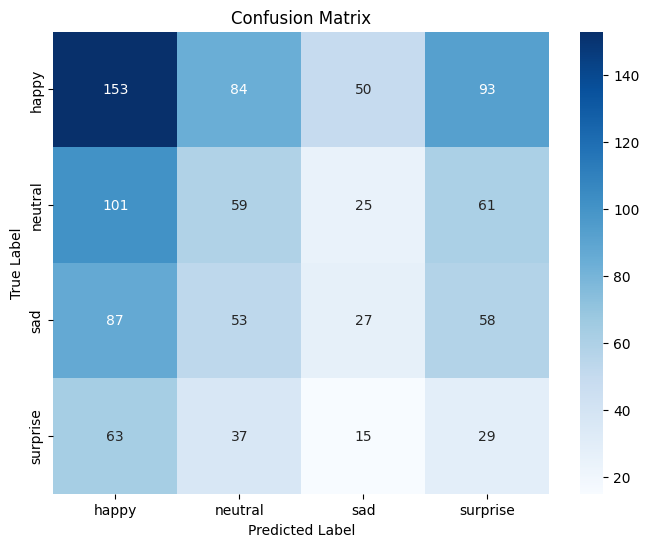

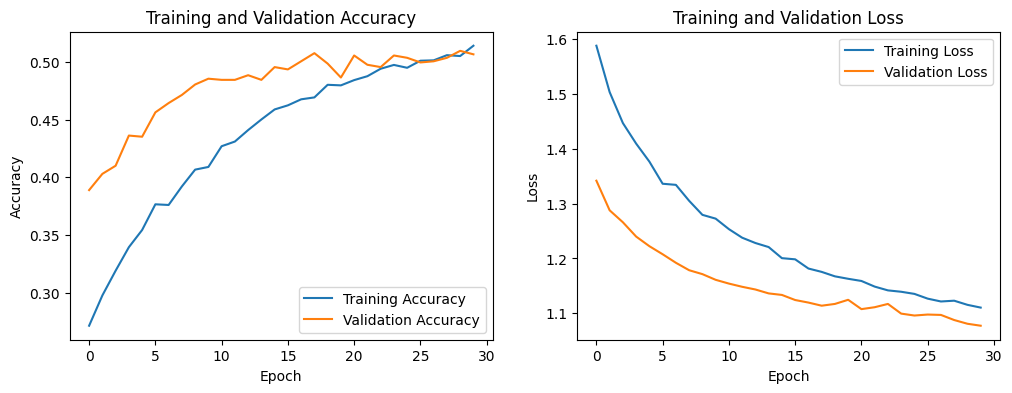

In [16]:
# Evaluate the second CNN model on the test data
#model2_loss, model2_accuracy = model_2.evaluate(normalized_val_ds_rgb)
model2_loss, model2_accuracy = model_2.evaluate(normalized_val_ds_grey)

print(f"Base Model Test Loss: {model2_loss}")
print(f"Base Model Test Accuracy: {model2_accuracy}")

# Get predictions on the test data
#predictions2 = model_2.predict(normalized_val_ds_rgb)
predictions2 = model_2.predict(normalized_val_ds_grey)
predicted_labels2 = np.argmax(predictions2, axis=1)

# Get the true labels from the test dataset
#true_labels2 = np.concatenate([y for x, y in normalized_val_ds_rgb], axis=0)
true_labels2 = np.concatenate([y for x, y in normalized_val_ds_grey], axis=0)
true_labels2 = np.argmax(true_labels2, axis=1)

# Generate the confusion matrix
print(classification_report(true_labels2, predicted_labels2))
cm2 = confusion_matrix(true_labels2, predicted_labels2)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=val_class_names, yticklabels=val_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

**Observations and Insights:**
- The larger convolutional neural network performed slightly worse than the first model in terms of accuracy and F1 score.
- Manual testing with different optimization algorithms revealed Lamb produced the highest accuracy score.
- Manual testing with different activation functions for the output layer revealed no significant difference between sigmoid, softmax, squareplus, or tanh.
- There was no significant difference in the accuracy or F1 score when using the greyscale images compared to the RGB ones.
- Validation accuracy was consistently more accurate than training accuracy.

## **Think About It:**

* Did the models have a satisfactory performance? If not, then what are the possible reasons?
* Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?

## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

## **VGG16 Model**

### **Importing the VGG16 Architecture**

### **Model Building**

- Import VGG16 upto the layer of your choice and add Fully Connected layers on top of it.

In [17]:
# Load VGG16 model without the top classification layer
vgg = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the layers up to layer 50
for layer in vgg.layers[:51]:
    layer.trainable = False

# Create a new sequential model
model_vgg = Sequential()

# Add the layers from VGG16 up to layer 50
for layer in vgg.layers[:51]:
    model_vgg.add(layer)

# Add custom classification layers on top
model_vgg.add(BatchNormalization()) # Added Batch Normalization
model_vgg.add(Dense(512, activation='silu'))
model_vgg.add(BatchNormalization()) # Added Batch Normalization
model_vgg.add(Dropout(0.5))
model_vgg.add(Dense(256, activation='gelu'))
model_vgg.add(BatchNormalization()) # Added Batch Normalization
model_vgg.add(Dropout(0.5))
model_vgg.add(Dense(128, activation='relu'))
model_vgg.add(BatchNormalization()) # Added Batch Normalization
model_vgg.add(Dropout(0.5))
model_vgg.add(Dense(64, activation='silu'))
model_vgg.add(BatchNormalization()) # Added Batch Normalization
model_vgg.add(Dropout(0.5))
model_vgg.add(Flatten())
model_vgg.add(Dense(len(train_class_names), activation='softmax'))

### **Compiling and Training the VGG16 Model**

In [18]:
# Compile the VGG16 model
#model_vgg.compile(optimizer=keras.optimizers.Adadelta(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
#model_vgg.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
#model_vgg.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])
model_vgg.compile(optimizer=keras.optimizers.Lamb(learning_rate=0.0001), loss=CategoricalCrossentropy(), metrics=['accuracy'])

# Define callbacks
model_vgg_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    ModelCheckpoint('best_model_vgg.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

# Fit and train the VGG Model
history_vgg = model_vgg.fit(
    normalized_train_ds_rgb,
    validation_data=normalized_val_ds_rgb,
    epochs=30,
    callbacks=model_vgg_callbacks
)

Epoch 1/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.2517 - loss: 2.2443
Epoch 1: val_loss improved from None to 1.32068, saving model to best_model_vgg.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 138s 353ms/step - accuracy: 0.2566 - loss: 2.2132 - val_accuracy: 0.3367 - val_loss: 1.3207
Epoch 2/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.2609 - loss: 2.1309
Epoch 2: val_loss improved from 1.32068 to 1.29641, saving model to best_model_vgg.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 130s 344ms/step - accuracy: 0.2665 - loss: 2.0634 - val_accuracy: 0.3769 - val_loss: 1.2964
Epoch 3/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.2830 - loss: 1.9312
Epoch 3: val_loss improved from 1.29641 to 1.27416, saving model to best_model_vgg.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 131s 346ms/step - accuracy: 0.2851 - loss: 1.9150 - val_accuracy: 0.3859 - val_loss: 1.2742
Epoch 4/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.2977 - loss: 1.8101
Epoch 4: val_loss imp

### **Evaluating the VGG16 model**

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 263ms/step - accuracy: 0.5025 - loss: 1.1615
VGG16 Model Test Loss: 1.161490559577942
VGG16 Model Test Accuracy: 0.5025125741958618
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 274ms/step
              precision    recall  f1-score   support

           0       0.36      0.35      0.35       380
           1       0.19      0.20      0.19       246
           2       0.20      0.22      0.21       225
           3       0.16      0.15      0.15       144

    accuracy                           0.25       995
   macro avg       0.23      0.23      0.23       995
weighted avg       0.25      0.25      0.25       995



2025-09-14 12:18:44.574634: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


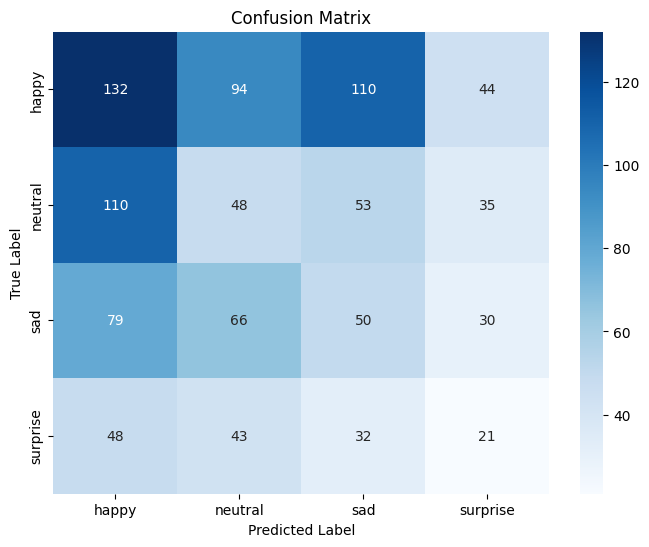

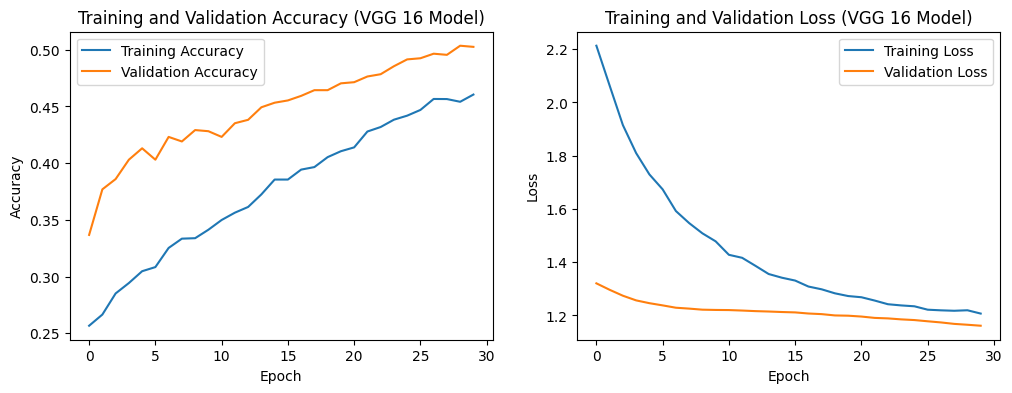

In [19]:
# Evaluate the VGG 16 Model on the test data
loss_vgg, accuracy_vgg = model_vgg.evaluate(normalized_val_ds_rgb)

print(f"VGG16 Model Test Loss: {loss_vgg}")
print(f"VGG16 Model Test Accuracy: {accuracy_vgg}")

# Get predictions on the test data
predictions_vgg = model_vgg.predict(normalized_val_ds_rgb)
predicted_labels_vgg = np.argmax(predictions_vgg, axis=1)

# Get the true labels from the test dataset
true_labels_vgg = np.concatenate([y for x, y in normalized_val_ds_rgb], axis=0)
true_labels_vgg = np.argmax(true_labels_vgg, axis=1)

# Generate the confusion matrix
print(classification_report(true_labels_vgg, predicted_labels_vgg))
cm_vgg = confusion_matrix(true_labels_vgg, predicted_labels_vgg)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', xticklabels=val_class_names, yticklabels=val_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot training and validation accuracy for the VGG 16 Model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (VGG 16 Model)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss for the VGG 16 Model
plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Training Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (VGG 16 Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Think About It:**

- What do you infer from the general trend in the training performance?
- Is the training accuracy consistently improving?
- Is the validation accuracy also improving similarly?

**Observations and Insights:**
- The VGG16 model with added dense layers performed worse in terms of accuracy and F1 score compared to the previous two models.
- However, importing 50 layers instead of 20 layers did improve its accuracy.
- Manual testing with different optimization algorithms revealed Lamb produced the highest accuracy score.
- Validation accuracy was consistently more accurate than training accuracy.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

## **ResNet V2 Model**

### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [25]:
# Define callbacks
model_resnet_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    ModelCheckpoint('best_resnet_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

def build_resnet_model(hp):
    # Load ResNet50V2 model without the top classification layer
    resnet = ResNet50V2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
    
    # Freeze the layers up to layer 50
    for layer in resnet.layers[:51]:
        layer.trainable = False
    
    # Create a new sequential model
    model_resnet = Sequential()
    
    # Add the ResNet model as a layer
    model_resnet.add(resnet)
    
    # Add custom classification layers on top
    model_resnet.add(BatchNormalization()) # Added Batch Normalization
    model_resnet.add(Dense(units=hp.Int("units", min_value=256, max_value=1024, step=128), activation=hp.Choice("activation1", ["relu", "silu", "celu", "gelu"])))
    model_resnet.add(BatchNormalization()) # Added Batch Normalization
    model_resnet.add(Dropout(0.5))
    model_resnet.add(Dense(units=hp.Int("units", min_value=128, max_value=512, step=64), activation=hp.Choice("activation2", ["relu", "silu", "celu", "gelu"])))
    model_resnet.add(BatchNormalization()) # Added Batch Normalization
    model_resnet.add(Dropout(0.5))
    model_resnet.add(Dense(units=hp.Int("units", min_value=64, max_value=256, step=32), activation=hp.Choice("activation3", ["relu", "silu", "celu", "gelu"])))
    model_resnet.add(BatchNormalization()) # Added Batch Normalization
    model_resnet.add(Dropout(0.5))
    model_resnet.add(Dense(units=hp.Int("units", min_value=32, max_value=128, step=16), activation=hp.Choice("activation4", ["relu", "silu", "celu", "gelu"])))
    model_resnet.add(BatchNormalization()) # Added Batch Normalization
    model_resnet.add(Dropout(0.5))
    model_resnet.add(Flatten())
    model_resnet.add(Dense(len(train_class_names), activation=hp.Choice("activation_output", ["softmax", "squareplus", "sigmoid", "tanh"])))

    # Learning rate range
    rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    
    # Define the optimizer choice
    optimizer_choice = hp.Choice('optimizer', values=['adamw', 'lamb', 'sgd', 'rmsprop'])
    if optimizer_choice == 'adamw':
        optimizer = tf.keras.optimizers.AdamW(learning_rate=rate)
    elif optimizer_choice == 'lamb':
        optimizer = tf.keras.optimizers.Lamb(learning_rate=rate)
    elif optimizer_choice == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=rate)
    
    # Compile the model
    loss=tf.keras.losses.CategoricalCrossentropy()
    model_resnet.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])
    return model_resnet

### **Compiling and Training the Model**

In [26]:
# Fit the model and print its summary
model_resnet = build_resnet_model(kt.HyperParameters())
model_resnet.summary()

# Search for the best hyperparameters optimizing for validation accuracy
resnet_tuner = kt.RandomSearch(
    hypermodel=build_resnet_model,
    objective="val_accuracy",
    max_trials=25,
    executions_per_trial=2,
    overwrite=True,
    directory="keras_tuner_emotion",
    project_name="emotion_resnet",
)
resnet_tuner.search_space_summary()
resnet_tuner.search(normalized_train_ds_rgb, validation_data=normalized_val_ds_rgb, epochs=30, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)])
resnet_tuner.results_summary()

# Get the top 2 models
resnet_models = resnet_tuner.get_best_models(num_models=2)
best_resnet_model = resnet_models[0]
best_resnet_model.summary()

Trial 25 Complete [01h 49m 30s]
val_accuracy: 0.47437185049057007

Best val_accuracy So Far: 0.7050251066684723
Total elapsed time: 23h 44m 55s
Results summary
Results in keras_tuner_emotion/emotion_resnet
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 08 summary
Hyperparameters:
units: 640
activation1: silu
activation2: gelu
activation3: relu
activation4: relu
activation_output: sigmoid
lr: 0.0005792676627629467
optimizer: lamb
Score: 0.7050251066684723

Trial 23 summary
Hyperparameters:
units: 896
activation1: celu
activation2: gelu
activation3: relu
activation4: celu
activation_output: squareplus
lr: 0.00011894173793507069
optimizer: adamw
Score: 0.7020100355148315

Trial 22 summary
Hyperparameters:
units: 384
activation1: silu
activation2: silu
activation3: gelu
activation4: silu
activation_output: squareplus
lr: 0.00018821084414612454
optimizer: adamw
Score: 0.69597989320755

Trial 09 summary
Hyperparameters:
units: 768
activation1: relu
activation2:

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'lamb', because it has 2 variables whereas the saved optimizer has 294 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 294 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 2, 2, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2, 2, 2048)     │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2, 2, 640)      │     1,311,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2, 2, 640)      │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 640)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2, 2, 640)      │       410,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 640)      │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 640)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2, 2, 640)      │       410,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 640)      │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 640)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2, 2, 640)      │       410,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 640)      │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 640)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │        10,244 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,135,556 (99.70 MB)

 Trainable params: 25,476,612 (97.19 MB)

 Non-trainable params: 658,944 (2.51 MB)

### **Evaluating the ResNet Model**

Epoch 1/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8745 - loss: 0.3443
Epoch 1: val_loss improved from None to 1.07060, saving model to best_resnet_model.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 176s 432ms/step - accuracy: 0.8902 - loss: 0.3063 - val_accuracy: 0.6905 - val_loss: 1.0706
Epoch 2/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9161 - loss: 0.2459
Epoch 2: val_loss did not improve from 1.07060
378/378 ━━━━━━━━━━━━━━━━━━━━ 161s 426ms/step - accuracy: 0.9258 - loss: 0.2227 - val_accuracy: 0.6995 - val_loss: 1.1649
Epoch 3/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9372 - loss: 0.1825
Epoch 3: val_loss did not improve from 1.07060
378/378 ━━━━━━━━━━━━━━━━━━━━ 162s 427ms/step - accuracy: 0.9424 - loss: 0.1670 - val_accuracy: 0.6925 - val_loss: 1.2287
Epoch 4/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9555 - loss: 0.1376
Epoch 4: val_loss did not improve from 1.07060
378/378 ━━━━━━━━━━━━━━━━━━━━ 161s 426ms/step - accuracy

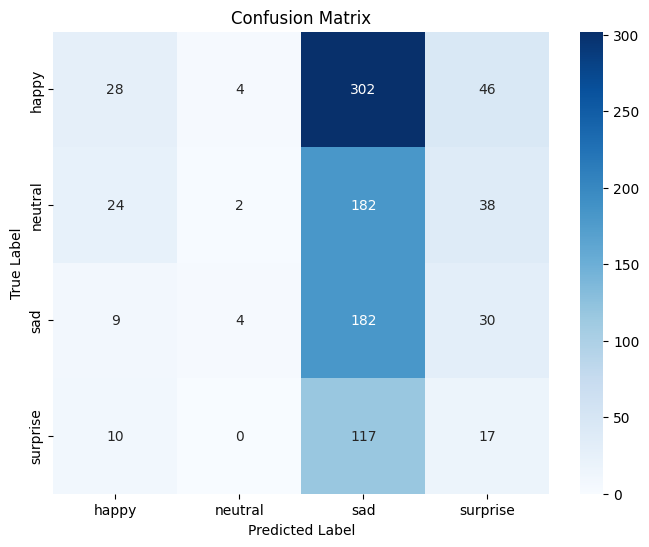

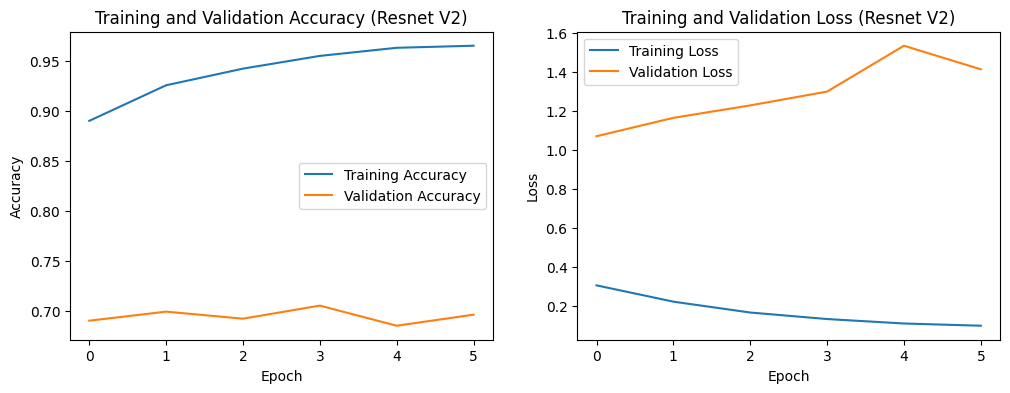

In [27]:
# Fit and train the best ResNet Model for more epochs
history_resnet = best_resnet_model.fit(
    normalized_train_ds_rgb,
    validation_data=normalized_val_ds_rgb,
    epochs=50,
    callbacks=model_resnet_callbacks
)

# Evaluate the Resnet v2 Model on the test data
loss_res, accuracy_res = model_resnet.evaluate(normalized_val_ds_rgb)

print(f"ResNet V2 Model Test Loss: {loss_res}")
print(f"ResNet V2 Model Test Accuracy: {accuracy_res}")

# Get predictions on the test data
predictions_res = model_resnet.predict(normalized_val_ds_rgb)
predicted_labels_res = np.argmax(predictions_res, axis=1)

# Get the true labels from the test dataset
true_labels_res = np.concatenate([y for x, y in normalized_val_ds_rgb], axis=0)
true_labels_res = np.argmax(true_labels_res, axis=1)

# Generate the confusion matrix
print(classification_report(true_labels_res, predicted_labels_res))
cm_res = confusion_matrix(true_labels_res, predicted_labels_res)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Blues', xticklabels=val_class_names, yticklabels=val_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot training and validation accuracy for the Resnet model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Resnet V2)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss for the Resnet model
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Resnet V2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Observations and Insights:**
- The Resnet V2 model with added dense layers performed produced the highest training accuracy (89.5%) and validation accuracy (70.5%).
- Importing additional layers from the pretrained model may improve accuracy further still.
- Manual testing showed that RMSprop is the optimization algorithm that produces the highest accuracy score.
- There is a modest amount of overfit in this model.

**Note: You can even go back and build your own architecture on top of the ResNet Transfer layer and see if you can improve the performance.**

## **EfficientNet V2 Model**

### **Model Building**

- Import EfficientNet upto the layer of your choice and add Fully Connected layers on top of it.

In [5]:
# Define callbacks
model_enet_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
    #ModelCheckpoint('best_enet_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

def build_enet_model(hp):
    # Load EfficientNetV2L model without the top classification layer
    enet = EfficientNetV2L(include_top=False, input_shape=(img_height, img_width, 3))
    
    # Freeze the layers up to layer 50
    for layer in enet.layers[:51]:
        layer.trainable = False
    
    # Create a new sequential model
    model_enet = Sequential()
    
    # Add the ResNet model as a layer
    model_enet.add(enet)
    
    # Add custom classification layers on top
    model_enet.add(BatchNormalization()) # Added Batch Normalization
    model_enet.add(Dense(units=hp.Int("units", min_value=256, max_value=1024, step=128), activation=hp.Choice("activation1", ["relu", "silu", "celu", "gelu"])))
    model_enet.add(BatchNormalization()) # Added Batch Normalization
    model_enet.add(Dropout(0.5))
    model_enet.add(Dense(units=hp.Int("units", min_value=128, max_value=512, step=64), activation=hp.Choice("activation2", ["relu", "silu", "celu", "gelu"])))
    model_enet.add(BatchNormalization()) # Added Batch Normalization
    model_enet.add(Dropout(0.5))
    model_enet.add(Dense(units=hp.Int("units", min_value=64, max_value=256, step=32), activation=hp.Choice("activation3", ["relu", "silu", "celu", "gelu"])))
    model_enet.add(BatchNormalization()) # Added Batch Normalization
    model_enet.add(Dropout(0.5))
    model_enet.add(Dense(units=hp.Int("units", min_value=32, max_value=128, step=16), activation=hp.Choice("activation4", ["relu", "silu", "celu", "gelu"])))
    model_enet.add(BatchNormalization()) # Added Batch Normalization
    model_enet.add(Dropout(0.5))
    model_enet.add(Flatten())
    model_enet.add(Dense(len(train_class_names), activation=hp.Choice("activation_output", ["softmax", "silu", "sigmoid", "gelu"])))
    
    # Learning rate range
    rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    
    # Define the optimizer choice
    optimizer_choice = hp.Choice('optimizer', values=['adadelta', 'adam', 'lamb', 'sgd', 'rmsprop'])
    if optimizer_choice == 'adadelta':
        optimizer = tf.keras.optimizers.Adadelta(learning_rate=rate)
    elif optimizer_choice == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=rate)
    elif optimizer_choice == 'lamb':
        optimizer = tf.keras.optimizers.Lamb(learning_rate=rate)
    elif optimizer_choice == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=rate)
    
    # Compile the model
    loss=tf.keras.losses.CategoricalCrossentropy()
    
    model_enet.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])
    return model_enet

### **Compiling and Training the Model**

In [ ]:
# Fit the model and print its summary
model_enet = build_enet_model(kt.HyperParameters())
model_enet.summary()

# Search for the best hyperparameters optimizing for validation accuracy
enet_tuner = kt.RandomSearch(
    hypermodel=build_enet_model,
    objective="val_accuracy",
    max_trials=25,
    executions_per_trial=2,
    overwrite=True,
    directory="keras_tuner_emotion",
    project_name="emotion_enet",
)
enet_tuner.search_space_summary()
enet_tuner.search(normalized_train_ds_rgb, validation_data=normalized_val_ds_rgb, epochs=50, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)])
enet_tuner.results_summary()

# Get the top 2 models
enet_models = enet_tuner.get_best_models(num_models=2)
best_enet_model = enet_models[0]
best_enet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)   │ (None, 2, 2, 1280)     │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2, 2, 1280)     │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2, 2, 256)      │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2, 2, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2, 2, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2, 2, 256)      │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,285,476 (451.22 MB)

 Trainable params: 117,043,908 (446.49 MB)

 Non-trainable params: 1,241,568 (4.74 MB)

Search space summary
Default search space size: 8
units (Int)
{'default': None, 'conditions': [], 'min_value': 256, 'max_value': 1024, 'step': 128, 'sampling': 'linear'}
activation1 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'silu', 'celu', 'gelu'], 'ordered': False}
activation2 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'silu', 'celu', 'gelu'], 'ordered': False}
activation3 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'silu', 'celu', 'gelu'], 'ordered': False}
activation4 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'silu', 'celu', 'gelu'], 'ordered': False}
activation_output (Choice)
{'default': 'softmax', 'conditions': [], 'values': ['softmax', 'silu', 'sigmoid', 'gelu'], 'ordered': False}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'adadelta', 'conditions': [], 'values': ['adadelta', 'ada

In [ ]:
# Fit and train the best EfficientNet Model for more epochs
history_enet = best_enet_model.fit(normalized_train_ds_rgb, validation_data=normalized_val_ds_rgb, epochs=50, callbacks=model_enet_callbacks)

# Evaluate the EfficientNet V2L Model on the test data
loss_enet, accuracy_enet = model_enet.evaluate(normalized_val_ds_rgb)

print(f"EfficientNet V2L Model Test Loss: {loss_enet}")
print(f"EfficientNet V2L Model Test Accuracy: {accuracy_enet}")

# Get predictions on the test data
predictions_enet = model_enet.predict(normalized_val_ds_rgb)
predicted_labels_enet = np.argmax(predictions_enet, axis=1)

# Get the true labels from the test dataset
true_labels_enet = np.concatenate([y for x, y in normalized_val_ds_rgb], axis=0)
true_labels_enet = np.argmax(true_labels_enet, axis=1)

# Generate the confusion matrix
print(classification_report(true_labels_enet, predicted_labels_enet))
cm_enet = confusion_matrix(true_labels_enet, predicted_labels_enet)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_enet, annot=True, fmt='d', cmap='Blues', xticklabels=val_class_names, yticklabels=val_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot training and validation accuracy for the Efficientnet Model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_enet.history['accuracy'], label='Training Accuracy')
plt.plot(history_enet.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Efficientnet)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss for the Efficientnet Model
plt.subplot(1, 2, 2)
plt.plot(history_enet.history['loss'], label='Training Loss')
plt.plot(history_enet.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Efficientnet)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Observations and Insights:**
- The Efficientnet V2M model with added dense layers performed much better than the Efficientnet V2M model from the previous assignment achieving high training accuracy (85%) and relatively high validation accuracy (68%).
- Importing additional layers from the pretrained model may improve accuracy further still.
- Manual testing showed that RMSprop is the optimization algorithm that produces the highest accuracy score.
- There is some overfit in this model.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance.**

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?
* Do you think our issue lies with 'rgb' color_mode?

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

### **Model Building**

- Try building a layer with 5 Convolutional Blocks and see if performance increases.

In [11]:
def build_cnn_model(hp):
    model = Sequential() # Create the sequential network
    model.add(Input(shape=(img_height, img_width, 1))) # The input layer needs 1 channel for the greyscale data
    model.add(Conv2D(32, kernel_size=(3, 3), padding='same')) # Input convolutional layer with 3x3 kernel
    model.add(LeakyReLU(negative_slope=hp.Float("activation1", min_value=0.1, max_value=0.5, step=0.1))) # Activation
    model.add(Conv2D(32, kernel_size=(3, 3), padding='same')) # Hidden convolutional layer
    model.add(LeakyReLU(negative_slope=hp.Float("activation2", min_value=0.1, max_value=0.5, step=0.1))) # Activation
    model.add(MaxPooling2D(pool_size=(2, 2))) # Pooling layer
    model.add(BatchNormalization())
    model.add(Dense(
      # Tune number of neurons in this fully connected layer
      units=hp.Int("units", min_value=64, max_value=256, step=32),
      # Tune the activation function to use
      activation=hp.Choice("activation", ["relu", "silu", "celu", "gelu"]),
    ))
    model.add(Dropout(rate=hp.Float("dropout1", min_value=0.1, max_value=0.6, step=0.1))) # Dropout to avoid overfitting
    model.add(BatchNormalization())
    model.add(Conv2D(32, kernel_size=(3, 3), padding='same')) # Hidden convolutional layer
    model.add(LeakyReLU(negative_slope=hp.Float("activation3", min_value=0.1, max_value=0.5, step=0.1))) # Activation
    model.add(MaxPooling2D(pool_size=(2, 2))) # Pooling layer
    model.add(BatchNormalization())
    model.add(Dense(
      # Tune number of neurons in this fully connected layer
      units=hp.Int("units", min_value=64, max_value=256, step=32),
      # Tune the activation function to use
      activation=hp.Choice("activation_inner1", ["relu", "silu", "celu", "gelu"]),
    ))
    model.add(Dropout(rate=hp.Float("dropout2", min_value=0.1, max_value=0.6, step=0.1))) # Dropout to avoid overfitting
    model.add(BatchNormalization())
    model.add(Conv2D(32, kernel_size=(3, 3), padding='same')) # Hidden convolutional layer
    model.add(LeakyReLU(negative_slope=hp.Float("activation4", min_value=0.1, max_value=0.5, step=0.1))) # Activation
    model.add(Conv2D(32, kernel_size=(3, 3), padding='same')) # Hidden convolutional layer
    model.add(LeakyReLU(negative_slope=hp.Float("activation5", min_value=0.1, max_value=0.5, step=0.1))) # Activation
    model.add(MaxPooling2D(pool_size=(2, 2))) # Pooling layer
    model.add(BatchNormalization())
    model.add(Flatten()) # Reshape into 1-D vector
    model.add(Dense(
      # Tune number of neurons in this fully connected layer
      units=hp.Int("units", min_value=64, max_value=256, step=32),
      # Tune the activation function to use
      activation=hp.Choice("activation_inner2", ["relu", "silu", "celu", "gelu"]),
    ))
    model.add(Dropout(rate=0.5)) # Dropout 50% to avoid overfitting
    model.add(BatchNormalization())
    model.add(Dense(len(train_class_names), activation=hp.Choice("activation_output", ["softmax", "squareplus", "sigmoid", "tanh"]))) # Output layer

    # Tune the learning rate
    rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    #opt=tf.keras.optimizers.Adadelta(learning_rate=rate)
    #opt=tf.keras.optimizers.Adam(learning_rate=rate)
    #opt=tf.keras.optimizers.Lamb(learning_rate=rate)
    opt=tf.keras.optimizers.RMSprop(learning_rate=rate)
    loss=tf.keras.losses.CategoricalCrossentropy()

    # Compile the model
    model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])
    return model

### **Compiling and Training the Model**

In [14]:
# Fit the model and print its summary
model_final = build_cnn_model(kt.HyperParameters())
model_final.summary()

# Search for the best hyperparameters optimizing for validation accuracy
tuner = kt.RandomSearch(
    hypermodel=build_cnn_model,
    objective="val_accuracy",
    max_trials=25,
    executions_per_trial=2,
    overwrite=True,
    directory="keras_tuner_emotion",
    project_name="emotion_custom",
)
tuner.search_space_summary()
tuner.search(normalized_train_ds_grey, validation_data=normalized_val_ds_grey, epochs=30)
tuner.results_summary()

# Get the top 2 models
models = tuner.get_best_models(num_models=2)
best_model = models[0]
best_model.summary()

# Build and train the final CNN model
history_final = best_model.fit(normalized_train_ds_grey, validation_data=normalized_val_ds_grey, epochs=50)

Trial 7 Complete [00h 30m 24s]
val_accuracy: 0.7281407117843628

Best val_accuracy So Far: 0.7336683571338654
Total elapsed time: 03h 50m 05s

Search: Running Trial #8

Value             |Best Value So Far |Hyperparameter
0.4               |0.5               |activation1
0.5               |0.2               |activation2
160               |128               |units
gelu              |gelu              |activation
0.2               |0.4               |dropout1
0.2               |0.4               |activation3
gelu              |relu              |activation_inner1
0.4               |0.5               |dropout2
0.5               |0.4               |activation4
0.5               |0.3               |activation5
relu              |relu              |activation_inner2
softmax           |squareplus        |activation_output
0.00055076        |0.0035464         |lr

Epoch 1/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.4204 - loss: 1.4538 - val_accuracy: 0.3427 - val_loss: 1.3147


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



378/378 ━━━━━━━━━━━━━━━━━━━━ 45s 120ms/step - accuracy: 0.2594 - loss: 3.4088 - val_accuracy: 0.1789 - val_loss: 2.6129
Epoch 4/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 42s 110ms/step - accuracy: 0.2359 - loss: 2.6803 - val_accuracy: 0.2864 - val_loss: 1.8622
Epoch 5/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.2514 - loss: 2.2810 - val_accuracy: 0.2693 - val_loss: 1.3863
Epoch 6/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 45s 119ms/step - accuracy: 0.2471 - loss: 2.1217 - val_accuracy: 0.3658 - val_loss: 1.4706
Epoch 7/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 44s 115ms/step - accuracy: 0.2451 - loss: 2.0885 - val_accuracy: 0.2693 - val_loss: 2.2301
Epoch 8/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 43s 114ms/step - accuracy: 0.2268 - loss: 2.4291 - val_accuracy: 0.2834 - val_loss: 2.5860
Epoch 9/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.2660 - loss: 2.9651 - val_accuracy: 0.2975 - val_loss: 2.6200
Epoch 10/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.2372 - loss: 2.9845 - va

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



378/378 ━━━━━━━━━━━━━━━━━━━━ 36s 95ms/step - accuracy: 0.9132 - loss: 0.2321 - val_accuracy: 0.7166 - val_loss: 1.1004
Epoch 29/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.9183 - loss: 0.2195 - val_accuracy: 0.6874 - val_loss: 1.0796
Epoch 30/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.9233 - loss: 0.2064 - val_accuracy: 0.6995 - val_loss: 1.1109
Epoch 1/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.4361 - loss: 1.3585 - val_accuracy: 0.4744 - val_loss: 1.2561
Epoch 2/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.5660 - loss: 1.0303 - val_accuracy: 0.6010 - val_loss: 0.9269
Epoch 3/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.6335 - loss: 0.8822 - val_accuracy: 0.5799 - val_loss: 0.9711
Epoch 4/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.6665 - loss: 0.8064 - val_accuracy: 0.6231 - val_loss: 0.9000
Epoch 5/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.6942 - loss: 0.7526 - val_accu

...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



378/378 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.6480 - loss: 0.8581 - val_accuracy: 0.6332 - val_loss: 0.8873
Epoch 15/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.6557 - loss: 0.8404 - val_accuracy: 0.6543 - val_loss: 0.8334
Epoch 16/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.6655 - loss: 0.8271 - val_accuracy: 0.6503 - val_loss: 0.8331
Epoch 17/30
364/378 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6487 - loss: 0.8377

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



378/378 ━━━━━━━━━━━━━━━━━━━━ 39s 102ms/step - accuracy: 0.7820 - loss: 0.5556 - val_accuracy: 0.7226 - val_loss: 0.7711
Epoch 7/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.7881 - loss: 0.5519 - val_accuracy: 0.7106 - val_loss: 0.7654
Epoch 8/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 37s 99ms/step - accuracy: 0.7890 - loss: 0.5417 - val_accuracy: 0.7116 - val_loss: 0.7702
Epoch 9/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.7950 - loss: 0.5343 - val_accuracy: 0.7136 - val_loss: 0.7973
Epoch 10/50
273/378 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.7905 - loss: 0.5362

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



### **Evaluating the Model on Test Set**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24, 24, 128)    │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12, 12, 128)    │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 501,194 (1.91 MB)

 Trainable params: 250,116 (977.02 KB)

 Non-trainable params: 960 (3.75 KB)

...

 Optimizer params: 134,598 (525.78 KB)

Epoch 1/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.8588 - loss: 0.3705 - val_accuracy: 0.7246 - val_loss: 0.8578
Epoch 2/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step - accuracy: 0.8581 - loss: 0.3684 - val_accuracy: 0.7317 - val_loss: 0.9423
Epoch 3/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step - accuracy: 0.8599 - loss: 0.3681 - val_accuracy: 0.7186 - val_loss: 0.9488
Epoch 4/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.8621 - loss: 0.3545 - val_accuracy: 0.7236 - val_loss: 0.8682
Epoch 5/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.8594 - loss: 0.3638 - val_accuracy: 0.7015 - val_loss: 1.0448
Epoch 6/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.8628 - loss: 0.3529 - val_accuracy: 0.7176 - val_loss: 0.9389
Epoch 7/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - accuracy: 0.8667 - loss: 0.3486 - val_accuracy: 0.7005 - val_loss: 0.9460
Epoch 8/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 29s 77ms/step - accuracy: 0.8672 - loss: 0

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



378/378 ━━━━━━━━━━━━━━━━━━━━ 29s 76ms/step - accuracy: 0.8991 - loss: 0.2668 - val_accuracy: 0.7296 - val_loss: 1.0146
Epoch 91/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.8986 - loss: 0.2671 - val_accuracy: 0.7206 - val_loss: 1.0389
Epoch 92/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.9008 - loss: 0.2666 - val_accuracy: 0.7266 - val_loss: 0.9699
Epoch 93/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.8987 - loss: 0.2722 - val_accuracy: 0.7286 - val_loss: 1.0331
Epoch 94/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.8979 - loss: 0.2731 - val_accuracy: 0.7136 - val_loss: 1.0707
Epoch 95/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.8961 - loss: 0.2764 - val_accuracy: 0.7216 - val_loss: 0.9705
Epoch 96/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.9005 - loss: 0.2714 - val_accuracy: 0.7246 - val_loss: 1.0261
Epoch 97/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.8981 - loss: 0.2712

2026-07-01 16:21:13.189528: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


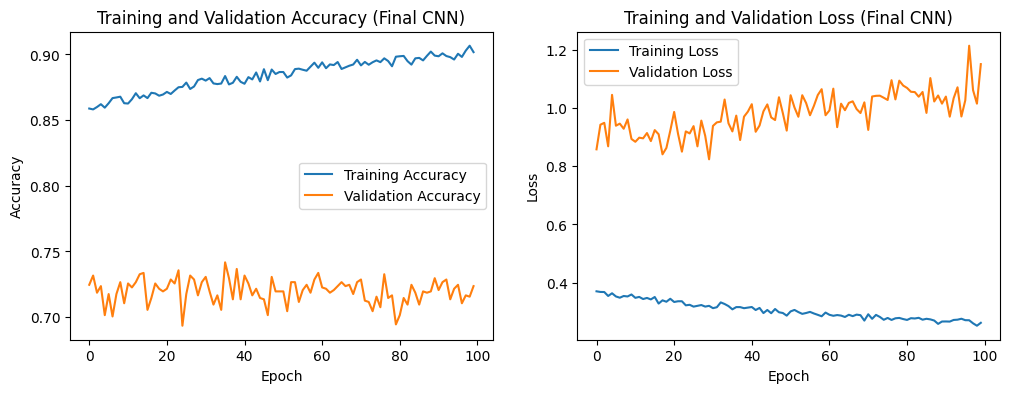

In [23]:
# After finding that the "best" model simply classifies every image as happy, we manually select the next best model
best_model = models[0]
best_model.summary()
second_best_model = models[1]
second_best_model.summary()

# Evaluate the Final Model on the test data
history_final = second_best_model.fit(normalized_train_ds_grey, validation_data=normalized_val_ds_grey, epochs=100)
loss_final, accuracy_final = second_best_model.evaluate(normalized_val_ds_grey)

print(f"Final CNN Model Test Loss: {loss_final}")
print(f"Final CNN Model Test Accuracy: {accuracy_final}")

# Get predictions on the test data
predictions_final = second_best_model.predict(normalized_val_ds_grey)
predicted_labels_final = np.argmax(predictions_final, axis=1)

# Get the true labels from the test dataset
true_labels_final = np.concatenate([y for x, y in normalized_val_ds_grey], axis=0)
true_labels_final = np.argmax(true_labels_final, axis=1)

# Generate the confusion matrix
print(classification_report(true_labels_final, predicted_labels_final))
cm_final = confusion_matrix(true_labels_final, predicted_labels_final)

# Plot training and validation accuracy for the Final Model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_final.history['accuracy'], label='Training Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Final CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss for the Efficientnet Model
plt.subplot(1, 2, 2)
plt.plot(history_final.history['loss'], label='Training Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Final CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Observations and Insights:**
- This model achieved a relatively good F1 score simply by classifying everything as happy.

### **Plotting the Confusion Matrix for the chosen final model**

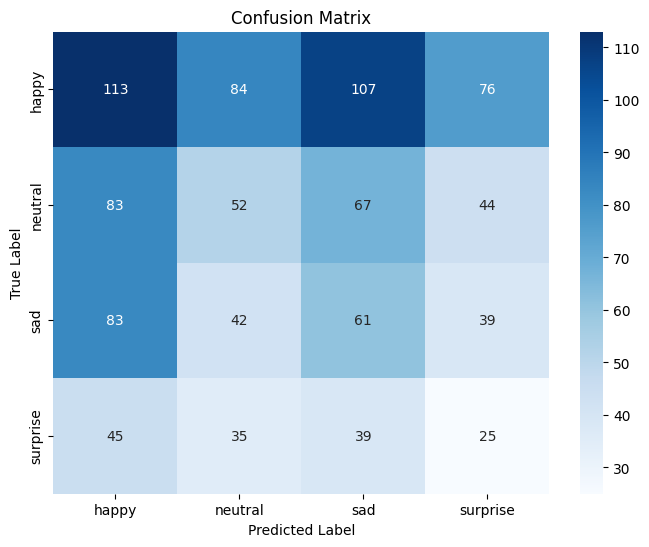

In [22]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=val_class_names, yticklabels=val_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Observations and Insights:**
- Unfortunately after 25 rounds of hyperparameter tuning with Keras, this model seems to achieve moderate validation accuracy of 69% by classifying every image as happy.

## **Conclusion:**
The Resnet V2 model with custom layers added on top offers the highest training and validation accuracy.  It is worth trying to find better hyperparameters for the Resnet V2 with a Keras tuner before finalizing it for produciton use cases.  It is also worth experimenting with importing additional layers from the pretained Resnet V2M model.

Newer and larger pretrained models such as Efficientnet V2M are also worth exploring as time and budgets allow.

Unfortunately the VGG16 model with custom layers repeatedly converged on a lazy solution that predicts every emotion depicted is happy.

### **Insights**

### **Refined insights**:
- Simple models may perform well since they are able to identify a relatively small set of visual features (such as a smile, tears, or open mouth) that reliably indicate one of the four categories of expression.  However, pretrained models perform better and achieve considerable accuracy gains when at least 50 layers are used.  Pretrained models may also be more accurate when when trying to categorize images of human facial expressions into more than 4 categories.

### **Comparison of various techniques and their relative performance**:
- Increasing the number of epochs from 20 to 30 improved results for most models.
- There were no meaningful differences between models' accuracy when trained on the RGB vs. greyscale images.
- Adding dropout layers reduced overfit in all models where it was used.
- Models may superficially appear to be accurate by finding the most common class/category and predict every instance to be the most common from the training dataset.

### **Proposal for the final solution design**:
- I would adopt the Resnet V2 model with custom layers added on top for the final solution since it has the highest training and validation accuracy score and could be further improved by experimenting with the number of layers imported from the pretrained model as well as the fully connected layers added on top.
- I would augment the training dataset with additional examples of the poorest performing category (sadness in this case).
- I would augment the training dataset with cropped, rotated, and zoomed transformations on the original images.
- Further improvements may be possible by tuning the parameters passed to the leaky relu activation function used in hidden layers.
- Further improvements may be possible by trying additional activiation functions for the output layer.
- Further improvements may be possible by tuning dropout rates after fully connected hidden layers.
- Further improvements may be possible by importing additional layers of the pretrained Resnet V2 model.